<a href="https://colab.research.google.com/github/maierav/claupenscope/blob/main/notebooks/rf_population_001637.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-session population RF analysis — dandiset 001637

**Data.** OpenScope Predictive Processing dandiset 001637 (post-2026-04 release) — 46 ecephys sessions across 14 subjects, each with 4–6 simultaneous Neuropixels 1.0 probes. Every session contains an `rf_mapping` block of sparse-grid stimuli.

**Approach.** A first-pass loop streams each NWB, bins spikes around RF onsets (SUA + `default_qc`), computes a baseline-subtracted firing-rate map per unit, and stores **per-unit summaries** (probe, depth on shank, peak ΔFR, RF centre az/el, half-max area) to `results/rf_cache/<asset_id[:8]>.pkl`. The loop is **resume-safe**: re-runs only process new sessions. Once cached, all aggregated figures regenerate in seconds.

**Figures.**
1. Subject × probe yield heat-map (visual fraction).
2. Aggregate retinotopic coverage per probe — RF-centre density across all sessions.
3. Visually-responsive fraction vs cortical depth, pooled across sessions per probe.
4. RF peak ΔFR vs cortical depth (mean ± 95 % CI per depth bin, per probe).
5. RF size (half-max area in deg²) — distribution per subject.

All figures are written to disk as vector PDF + PNG.

In [1]:
!pip install -q git+https://github.com/maierav/claupenscope.git \
    dandi remfile h5py pynwb scipy matplotlib numpy pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.2/386.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os, sys, time, pickle, gc
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from dandi.dandiapi import DandiAPIClient

from openscope_pp.loaders.streaming import open_nwb
from openscope_pp.loaders.trials import load_trials

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 9.5, "axes.labelsize": 10, "axes.titlesize": 10.5,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "legend.fontsize": 8.0, "legend.frameon": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

# Probe-letter palette (Wong colour-blind-friendly)
PROBE_PALETTE = {"A": "#0072B2", "B": "#D55E00",
                  "C": "#009E73", "D": "#CC79A7",
                  "E": "#F0E442", "F": "#56B4E9"}
PROBES_KEEP = ["A", "B", "C", "D"]   # focus on first four

# RF + analysis windows
RF_WIN     = (-0.30, 0.50)
BL_WIN     = (-0.20, 0.00)
RESP_WIN   = (0.03, 0.20)
BIN_SIZE   = 0.010
RF_SMOOTH  = 0.8
VIS_THR    = 5.0    # peak ΔFR threshold for "visually responsive" (spk/s)

DANDISET_ID = "001637"
CACHE_DIR   = "results/rf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# Limit how many uncached sessions to process this run; set to None
# for "all". Keep cached entries always.
N_NEW_THIS_RUN = None

print("Setup complete.  Cache:", CACHE_DIR)

Setup complete.  Cache: results/rf_cache


## 1. Stream + cache per-session RF summaries

Each cached file holds a *small* dict — a per-unit DataFrame plus a tiny session-meta block. There is no full PSTH or full RF map per unit, so even the full 46-session cache is small (~hundreds of KB total). The first run streams every NWB; subsequent runs skip them entirely.

In [3]:
def decode_str(arr):
    if arr.dtype.kind in ("S", "O"):
        return np.array([v.decode() if isinstance(v, bytes) else str(v) for v in arr])
    return arr

def bin_spikes(uid_arr, spikes, index, onsets, window, bin_size):
    pre, post = window
    edges   = np.arange(pre, post + bin_size, bin_size)
    centers = 0.5 * (edges[:-1] + edges[1:])
    out = np.zeros((len(onsets), len(uid_arr), len(centers)), dtype=np.float32)
    for j, uid in enumerate(uid_arr):
        i0 = int(index[uid - 1]) if uid > 0 else 0
        s  = spikes[i0:int(index[uid])]
        if not len(s):
            continue
        for i, t0 in enumerate(onsets):
            lo = int(np.searchsorted(s, t0 + pre))
            hi = int(np.searchsorted(s, t0 + post))
            if lo < hi:
                cnt, _ = np.histogram(s[lo:hi] - t0, bins=edges)
                out[i, j, :] = cnt / bin_size
    return out, centers

def probe_letter(name: str) -> str:
    "Return a single uppercase letter from a device_name like 'ProbeA' / 'imec0'."
    s = name.strip()
    return s[-1].upper() if s and s[-1].isalpha() else s[-1].upper() if s else "?"

def process_session(asset, force=False):
    """Stream one NWB, compute per-unit RF summaries, cache to pickle.
    Returns the cache file path (skipping if already present unless force)."""
    asset_id   = asset.identifier
    subject_id = asset.path.split("/")[0]
    cache_path = os.path.join(CACHE_DIR, f"{asset_id[:8]}.pkl")
    if os.path.exists(cache_path) and not force:
        return cache_path, "cached"

    t0 = time.time()
    handle = open_nwb(asset_id)
    try:
        trials = load_trials(handle)
        h5     = handle.h5
        rf_trials = trials[trials["block_kind"] == "rf_mapping"].copy()
        if len(rf_trials) < 50:
            return cache_path, f"skip (rf trials={len(rf_trials)})"

        xs_grid = np.sort(rf_trials["x"].dropna().unique())
        ys_grid = np.sort(rf_trials["y"].dropna().unique())

        units_grp     = h5["units"]
        decoder_label = decode_str(units_grp["decoder_label"][:])
        default_qc    = units_grp["default_qc"][:].astype(bool)
        device_name   = decode_str(units_grp["device_name"][:])
        spike_times   = units_grp["spike_times"][:]
        spk_index     = units_grp["spike_times_index"][:]
        depth_um      = (np.asarray(units_grp["depth"][:]).astype(float)
                         if "depth" in units_grp else np.full(len(decoder_label), np.nan))

        is_sua  = (decoder_label == "sua") & default_qc
        sua_idx = np.where(is_sua)[0]
        if not len(sua_idx):
            return cache_path, "skip (no SUA)"

        x_trial = rf_trials["x"].values
        y_trial = rf_trials["y"].values
        onsets  = rf_trials["start_time"].values
        arr, t_centers = bin_spikes(sua_idx, spike_times, spk_index,
                                     onsets, RF_WIN, BIN_SIZE)

        rsp = (t_centers >= RESP_WIN[0]) & (t_centers < RESP_WIN[1])
        bl  = (t_centers >= BL_WIN[0])   & (t_centers < BL_WIN[1])

        n_units = len(sua_idx)
        rf_raw = np.zeros((n_units, len(ys_grid), len(xs_grid)), dtype=np.float32)
        for xi, x in enumerate(xs_grid):
            for yi, y in enumerate(ys_grid):
                m = (x_trial == x) & (y_trial == y)
                if not m.any(): continue
                rf_raw[:, yi, xi] = (np.nanmean(arr[m][:, :, rsp], axis=(0, 2))
                                    - np.nanmean(arr[m][:, :, bl ], axis=(0, 2)))
        del arr; gc.collect()

        # Per-unit summaries (no big arrays kept)
        rf_sm = np.array([gaussian_filter(rf_raw[u], RF_SMOOTH) for u in range(n_units)])
        peak  = rf_sm.reshape(n_units, -1).max(axis=1)
        # Argmax (yi, xi)
        flat_argmax = rf_sm.reshape(n_units, -1).argmax(axis=1)
        yi = flat_argmax // len(xs_grid)
        xi = flat_argmax %  len(xs_grid)
        cx = xs_grid[xi]; cy = ys_grid[yi]
        # Half-max area in deg² (number of grid cells > 0.5 * peak, scaled by cell area)
        if len(xs_grid) > 1 and len(ys_grid) > 1:
            cell_area = float((xs_grid[1] - xs_grid[0]) * (ys_grid[1] - ys_grid[0]))
        else:
            cell_area = float("nan")
        hm_area = np.array([
            (rf_sm[u] >= 0.5 * peak[u]).sum() * cell_area if peak[u] > 0 else np.nan
            for u in range(n_units)
        ], dtype=float)

        df = pd.DataFrame({
            "unit_idx":   sua_idx,
            "device_name": device_name[sua_idx],
            "probe":       [probe_letter(d) for d in device_name[sua_idx]],
            "depth_um":    depth_um[sua_idx],
            "peak_dfr":    peak,
            "rf_x":        cx,
            "rf_y":        cy,
            "rf_hm_area":  hm_area,
        })
        meta = {
            "asset_id":  asset_id,
            "subject_id": subject_id,
            "asset_path": asset.path,
            "xs_grid":   xs_grid,
            "ys_grid":   ys_grid,
            "n_rf_trials": int(len(rf_trials)),
            "runtime_s": time.time() - t0,
        }
        with open(cache_path, "wb") as fh:
            pickle.dump({"meta": meta, "units": df}, fh)
        return cache_path, f"new ({len(df)} units, {time.time()-t0:.0f} s)"
    finally:
        try: handle.close()
        except Exception: pass

# Build asset list (sorted for reproducibility)
client = DandiAPIClient()
ds     = client.get_dandiset(DANDISET_ID)
assets = sorted(list(ds.get_assets()), key=lambda a: a.path)
print(f"Dandiset {DANDISET_ID}: {len(assets)} assets")

n_processed = 0
for ai, a in enumerate(assets):
    cache_path, status = process_session(a)
    print(f"  [{ai+1:>2}/{len(assets)}] {a.path.split('/')[-1][:55]:55s}  {status}")
    if status.startswith("new"):
        n_processed += 1
        if N_NEW_THIS_RUN is not None and n_processed >= N_NEW_THIS_RUN:
            print(f"  reached N_NEW_THIS_RUN={N_NEW_THIS_RUN}; stopping early")
            break

print(f"\nProcessed {n_processed} new sessions this run.")

Dandiset 001637: 46 assets


/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)


  [ 1/46] sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_eceph  new (1395 units, 96 s)


/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)


  [ 2/46] sub-820454_ses-ecephys-820454-2025-11-05-15-21-15_eceph  new (1510 units, 91 s)


...

  [44/46] sub-834687_ses-ecephys-834687-2026-03-19-16-06-07_eceph  new (1070 units, 86 s)


/usr/local/lib/python3.12/dist-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e

  [45/46] sub-834691_ses-ecephys-834691-2026-02-16-11-02-15_eceph  new (1464 units, 77 s)


/usr/local/lib/python3.12/dist-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e

  [46/46] sub-834691_ses-ecephys-834691-2026-02-17-10-49-35_eceph  new (676 units, 49 s)

Processed 46 new sessions this run.


## 2. Aggregate cache → one DataFrame

Every cached session contributes its per-unit table; we concatenate, attach `subject_id`, and keep only the four canonical probes (A–D). One unified table makes every figure below a few lines.

In [4]:
import glob
rows = []
session_meta = []
for fp in sorted(glob.glob(os.path.join(CACHE_DIR, "*.pkl"))):
    with open(fp, "rb") as fh:
        d = pickle.load(fh)
    df  = d["units"].copy()
    md  = d["meta"]
    df["asset_id"]   = md["asset_id"][:8]
    df["subject_id"] = md["subject_id"]
    rows.append(df)
    session_meta.append(md)

if not rows:
    raise RuntimeError("No cache files found — run the previous cell first.")

ALL = pd.concat(rows, ignore_index=True)
ALL = ALL[ALL["probe"].isin(PROBES_KEEP)].reset_index(drop=True)
ALL["is_visual"] = ALL["peak_dfr"] >= VIS_THR

n_sessions = ALL["asset_id"].nunique()
n_subjects = ALL["subject_id"].nunique()
n_units    = len(ALL)
n_visual   = int(ALL["is_visual"].sum())
print(f"Aggregated  {n_sessions} sessions  ·  {n_subjects} subjects  ·  "
      f"{n_units} SUA  ·  {n_visual} visually responsive ({100*n_visual/max(n_units,1):.1f} %)")
print("\nUnits per probe (A-D):")
print(ALL.groupby("probe").agg(
    n_sua=("unit_idx", "size"),
    n_visual=("is_visual", "sum"),
    visual_frac=("is_visual", "mean"),
    median_depth=("depth_um", "median"),
    median_peak=("peak_dfr", "median"),
).round(2).to_string())

Aggregated  46 sessions  ·  14 subjects  ·  24897 SUA  ·  4641 visually responsive (18.6 %)

Units per probe (A-D):
       n_sua  n_visual  visual_frac  median_depth  median_peak
probe                                                         
A       6444       533         0.08       2005.36         1.89
B       5868       803         0.14       2117.80         1.79
C       6304      1925         0.31       1764.90         3.04
D       6281      1380         0.22       1783.78         2.30


## Figure 1 — Subject × probe yield heat-map

Each cell shows the fraction of SUA on that subject/probe whose peak ΔFR clears the visual threshold (≥ 5 spk·s⁻¹). The marginal bars summarise the per-subject totals (sum across probes) and the per-probe totals (sum across subjects).

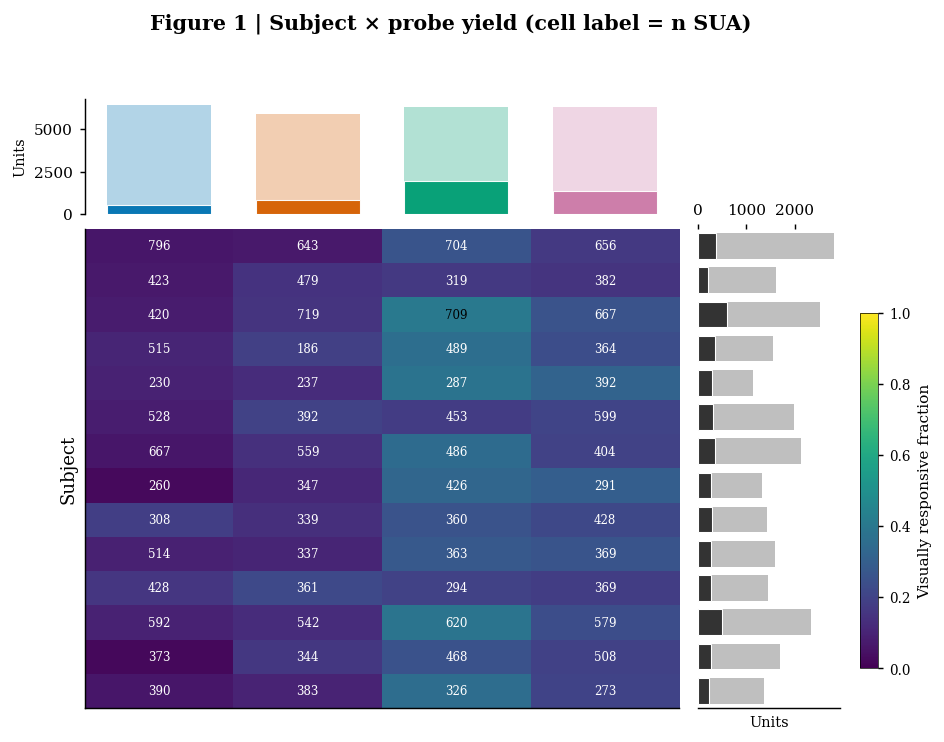

6721

In [5]:
tot = ALL.groupby(["subject_id", "probe"]).agg(
    n_sua=("unit_idx", "size"),
    n_visual=("is_visual", "sum"),
).reset_index()
tot["visual_frac"] = tot["n_visual"] / tot["n_sua"].clip(lower=1)

subjects = sorted(tot["subject_id"].unique())
M = np.full((len(subjects), len(PROBES_KEEP)), np.nan)
N = np.zeros_like(M)
for si, s in enumerate(subjects):
    for pi, p in enumerate(PROBES_KEEP):
        sub = tot[(tot["subject_id"] == s) & (tot["probe"] == p)]
        if len(sub):
            M[si, pi] = float(sub["visual_frac"].iloc[0])
            N[si, pi] = float(sub["n_sua"].iloc[0])

fig = plt.figure(figsize=(7.5, max(3.5, 0.32 * len(subjects) + 1.6)))
gs  = GridSpec(2, 2, width_ratios=[5, 1.2], height_ratios=[1.2, 5],
               hspace=0.05, wspace=0.05, figure=fig)
ax  = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1, aspect="auto",
               interpolation="nearest")
for si in range(len(subjects)):
    for pi in range(len(PROBES_KEEP)):
        if np.isnan(M[si, pi]):
            ax.text(pi, si, "·", ha="center", va="center", fontsize=10, color="0.6")
        else:
            ax.text(pi, si, f"{int(N[si, pi])}", ha="center", va="center",
                    fontsize=6.5, color="white" if M[si, pi] < 0.4 else "black")

ax.set_xticks(range(len(PROBES_KEEP)))
ax.set_xticklabels([f"Probe {p}" for p in PROBES_KEEP])
ax.set_yticks(range(len(subjects)))
ax.set_yticklabels([s.replace("sub-", "") for s in subjects], fontsize=7.5)
ax.set_xlabel("")
ax.set_ylabel("Subject", fontsize=10)
ax.tick_params(top=False, right=False)

# Top: per-probe totals
p_tot = ALL.groupby("probe").agg(n=("unit_idx", "size"),
                                   v=("is_visual", "sum")).reindex(PROBES_KEEP).fillna(0)
x = np.arange(len(PROBES_KEEP))
ax_top.bar(x, p_tot["n"].values, color=[PROBE_PALETTE[p] for p in PROBES_KEEP],
           alpha=0.30, edgecolor="none", width=0.7)
ax_top.bar(x, p_tot["v"].values, color=[PROBE_PALETTE[p] for p in PROBES_KEEP],
           alpha=0.95, edgecolor="white", lw=0.6, width=0.7)
ax_top.set_ylabel("Units", fontsize=8)
ax_top.tick_params(labelbottom=False)
ax_top.set_xticks([]); ax_top.spines["bottom"].set_visible(False)

# Right: per-subject totals
s_tot = ALL.groupby("subject_id").agg(n=("unit_idx", "size"),
                                       v=("is_visual", "sum")).reindex(subjects).fillna(0)
y = np.arange(len(subjects))
ax_rgt.barh(y, s_tot["n"].values, color="0.75", height=0.75, edgecolor="none")
ax_rgt.barh(y, s_tot["v"].values, color="#333333", height=0.75, edgecolor="white", lw=0.6)
ax_rgt.set_xlabel("Units", fontsize=8)
ax_rgt.tick_params(labelleft=False)
ax_rgt.set_yticks([]); ax_rgt.spines["left"].set_visible(False)
ax_rgt.invert_xaxis()
ax_rgt.xaxis.set_ticks_position("top")
ax_rgt.invert_xaxis()   # restore natural direction

cax = fig.add_axes([0.92, 0.16, 0.018, 0.45])
cb  = fig.colorbar(im, cax=cax)
cb.set_label("Visually responsive fraction", fontsize=8.5)
cb.ax.tick_params(labelsize=7.5)
cb.outline.set_linewidth(0.4)

fig.suptitle("Figure 1 | Subject × probe yield (cell label = n SUA)",
             y=0.99, fontweight="bold")
fig.savefig("rfpop_fig1_yield.pdf", dpi=200)
fig.savefig("rfpop_fig1_yield.png")
plt.show(); plt.close(fig); gc.collect()

## Figure 2 — Aggregate retinotopic coverage

Density of RF-centre positions across all sessions, separately for each probe. Coverage uniformity tells you whether the four probes were sampling overlapping or distinct retinotopic territory.

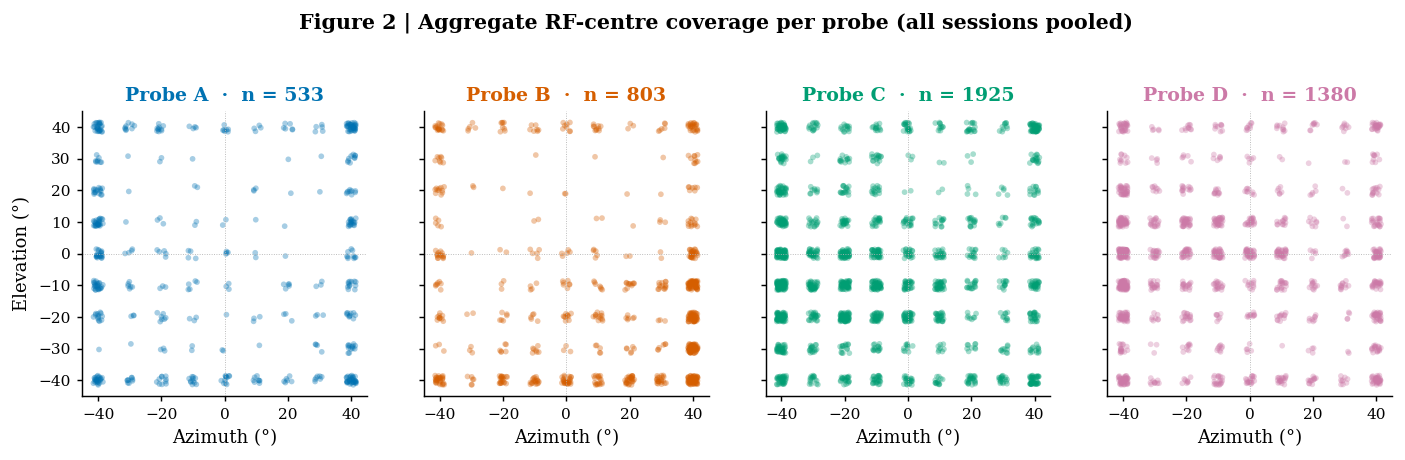

In [6]:
vis = ALL[ALL["is_visual"]]
if len(vis) == 0:
    print("No visually responsive units — skipping Figure 2.")
else:
    # Pick a common grid from the most-frequent xs/ys grid in the cache
    grids = [(tuple(m["xs_grid"]), tuple(m["ys_grid"])) for m in session_meta]
    common_grid = max(set(grids), key=grids.count)
    xs_grid = np.asarray(common_grid[0]); ys_grid = np.asarray(common_grid[1])
    pad = 5.0
    xlim = (xs_grid[0] - pad, xs_grid[-1] + pad)
    ylim = (ys_grid[0] - pad, ys_grid[-1] + pad)

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharex=True, sharey=True)
    for ax, p in zip(axes, PROBES_KEEP):
        sub = vis[vis["probe"] == p]
        col = PROBE_PALETTE[p]
        if len(sub):
            jitter_x = np.random.uniform(-1.5, 1.5, len(sub))
            jitter_y = np.random.uniform(-1.5, 1.5, len(sub))
            ax.scatter(sub["rf_x"] + jitter_x, sub["rf_y"] + jitter_y,
                       s=10, color=col, alpha=0.35, edgecolor="none", rasterized=True)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.axhline(0, color="0.7", lw=0.5, ls=":")
        ax.axvline(0, color="0.7", lw=0.5, ls=":")
        ax.set_title(f"Probe {p}  ·  n = {len(sub)}", color=col, fontweight="bold")
        ax.set_xlabel("Azimuth (°)")
    axes[0].set_ylabel("Elevation (°)")

    fig.suptitle("Figure 2 | Aggregate RF-centre coverage per probe (all sessions pooled)",
                 y=1.04, fontweight="bold")
    fig.savefig("rfpop_fig2_coverage.pdf", dpi=200)
    fig.savefig("rfpop_fig2_coverage.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 3 — Visually-responsive fraction vs cortical depth

All sessions pooled, per probe. Depth is binned in 100 µm steps; for each bin we plot the fraction of SUA that cleared the visual threshold, with a Wilson 95 % CI for the proportion.

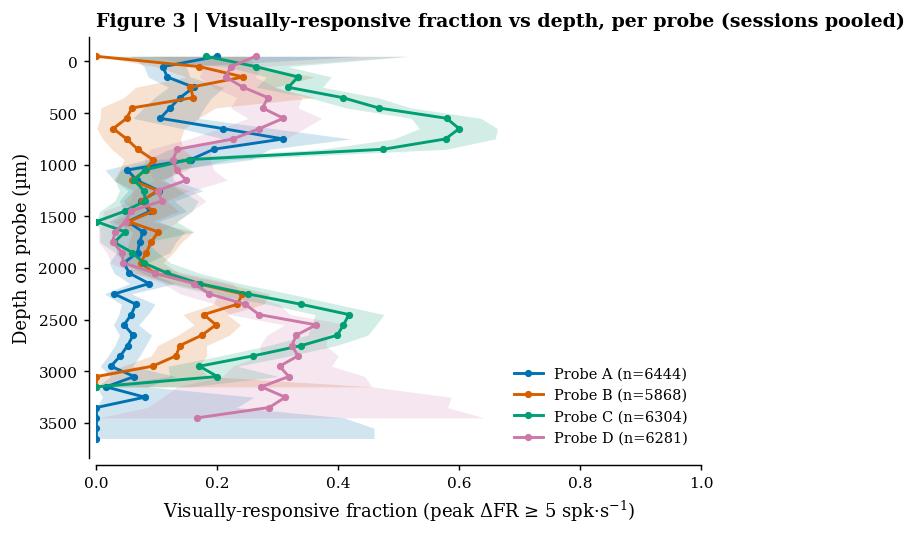

3261

In [7]:
from scipy.stats import beta

DEPTH_BIN_F3 = 100.0

def wilson_ci(k, n, alpha=0.05):
    if n <= 0:
        return np.nan, np.nan
    lo = beta.ppf(alpha/2,     k,     n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - alpha/2, k + 1, n - k    ) if k < n else 1.0
    return float(lo), float(hi)

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for p in PROBES_KEEP:
    sub = ALL[(ALL["probe"] == p) & ALL["depth_um"].notna()]
    if not len(sub): continue
    d_lo = float(np.floor(sub["depth_um"].min() / DEPTH_BIN_F3) * DEPTH_BIN_F3)
    d_hi = float(np.ceil(sub["depth_um"].max()  / DEPTH_BIN_F3) * DEPTH_BIN_F3)
    edges = np.arange(d_lo, d_hi + DEPTH_BIN_F3, DEPTH_BIN_F3)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.clip(np.digitize(sub["depth_um"].values, edges) - 1,
                      0, len(centers) - 1)
    n_bin = np.bincount(bin_idx, minlength=len(centers)).astype(float)
    k_bin = np.bincount(bin_idx, weights=sub["is_visual"].values.astype(float),
                        minlength=len(centers))
    keep = n_bin >= 5
    if not keep.any(): continue
    fr  = np.where(n_bin > 0, k_bin / np.maximum(n_bin, 1), np.nan)
    lo  = np.array([wilson_ci(int(k), int(n))[0] if n > 0 else np.nan
                    for k, n in zip(k_bin, n_bin)])
    hi  = np.array([wilson_ci(int(k), int(n))[1] if n > 0 else np.nan
                    for k, n in zip(k_bin, n_bin)])
    col = PROBE_PALETTE[p]
    ax.fill_betweenx(centers[keep], lo[keep], hi[keep], color=col, alpha=0.18, lw=0)
    ax.plot(fr[keep], centers[keep], color=col, lw=1.6, marker="o", ms=3,
            label=f"Probe {p} (n={int(n_bin.sum())})")

ax.invert_yaxis()
ax.set_xlabel(f"Visually-responsive fraction (peak ΔFR ≥ {VIS_THR:g} spk·s$^{{-1}}$)")
ax.set_ylabel("Depth on probe (µm)")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
ax.spines["left"].set_position(("outward", 4))
ax.spines["bottom"].set_position(("outward", 4))
ax.set_title("Figure 3 | Visually-responsive fraction vs depth, per probe (sessions pooled)",
             loc="left", fontweight="bold")
fig.savefig("rfpop_fig3_visfrac_vs_depth.pdf", dpi=200)
fig.savefig("rfpop_fig3_visfrac_vs_depth.png")
plt.show(); plt.close(fig); gc.collect()

## Figure 4 — Peak ΔFR vs cortical depth

Same depth bins as Figure 3, but the y-axis is the **peak ΔFR** of the smoothed RF map (spk·s⁻¹). Mean ± 95 % CI of the bootstrap (n = 1000).

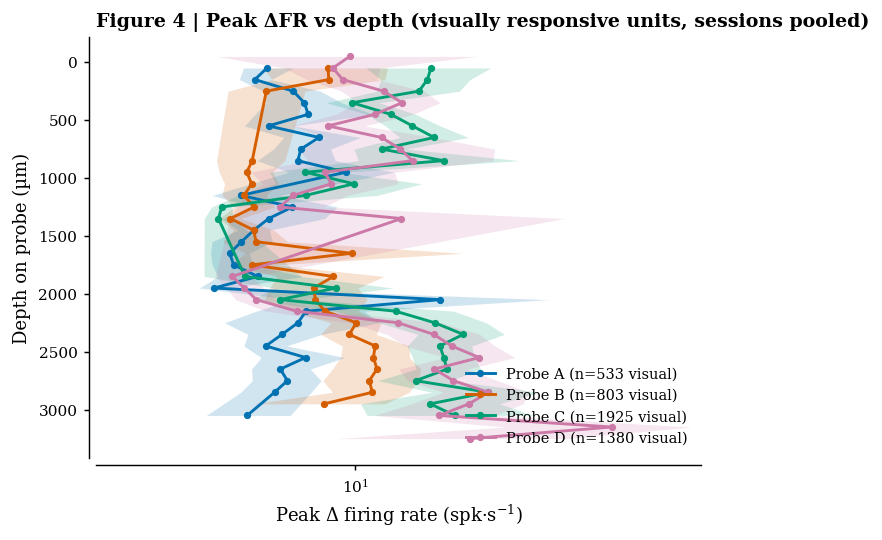

10337

In [8]:
DEPTH_BIN_F4 = 100.0
rng = np.random.default_rng(42)

def boot_ci(values, n_boot=1000, alpha=0.05):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return float("nan"), float("nan"), float("nan")
    idx = rng.integers(0, len(v), size=(n_boot, len(v)))
    means = v[idx].mean(axis=1)
    return float(v.mean()), float(np.quantile(means, alpha/2)), float(np.quantile(means, 1-alpha/2))

fig, ax = plt.subplots(figsize=(6.0, 4.2))
for p in PROBES_KEEP:
    sub = ALL[(ALL["probe"] == p) & ALL["depth_um"].notna() & ALL["is_visual"]]
    if not len(sub): continue
    d_lo = float(np.floor(sub["depth_um"].min() / DEPTH_BIN_F4) * DEPTH_BIN_F4)
    d_hi = float(np.ceil(sub["depth_um"].max()  / DEPTH_BIN_F4) * DEPTH_BIN_F4)
    edges = np.arange(d_lo, d_hi + DEPTH_BIN_F4, DEPTH_BIN_F4)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.clip(np.digitize(sub["depth_um"].values, edges) - 1,
                      0, len(centers) - 1)
    means, los, his, ns = [], [], [], []
    for b in range(len(centers)):
        v = sub.loc[bin_idx == b, "peak_dfr"].values
        m, lo, hi = boot_ci(v)
        means.append(m); los.append(lo); his.append(hi); ns.append(len(v))
    means, los, his, ns = map(np.asarray, (means, los, his, ns))
    keep = ns >= 5
    if not keep.any(): continue
    col = PROBE_PALETTE[p]
    ax.fill_betweenx(centers[keep], los[keep], his[keep], color=col, alpha=0.18, lw=0)
    ax.plot(means[keep], centers[keep], color=col, lw=1.6, marker="o", ms=3,
            label=f"Probe {p} (n={int(ns.sum())} visual)")

ax.invert_yaxis()
ax.set_xlabel("Peak Δ firing rate (spk·s$^{-1}$)")
ax.set_ylabel("Depth on probe (µm)")
ax.legend(loc="lower right")
ax.set_xscale("symlog", linthresh=1.0)
ax.spines["left"].set_position(("outward", 4))
ax.spines["bottom"].set_position(("outward", 4))
ax.set_title("Figure 4 | Peak ΔFR vs depth (visually responsive units, sessions pooled)",
             loc="left", fontweight="bold")
fig.savefig("rfpop_fig4_peak_vs_depth.pdf", dpi=200)
fig.savefig("rfpop_fig4_peak_vs_depth.png")
plt.show(); plt.close(fig); gc.collect()

## Figure 5 — RF size distribution per subject

RF size = area in deg² where the smoothed RF map is ≥ 50 % of its peak (a coarse FWHM-area measure that doesn't require Gaussian fitting). One violin per subject; box markers show the median and IQR.

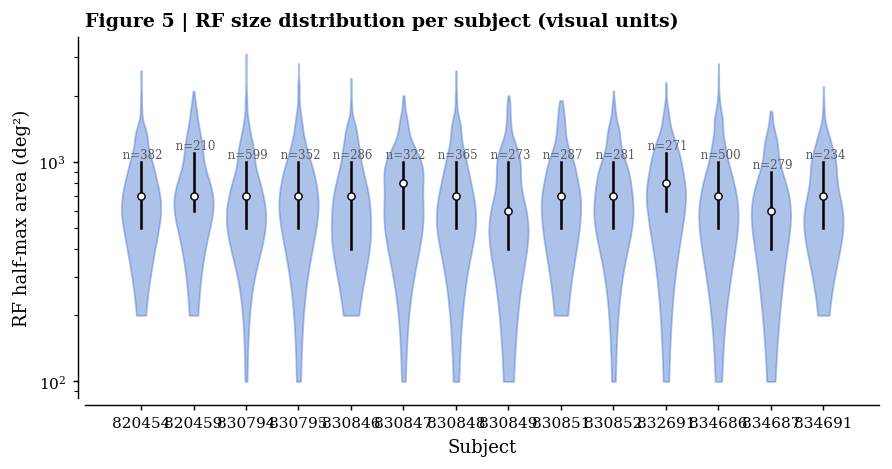

In [9]:
vis = ALL[ALL["is_visual"] & ALL["rf_hm_area"].notna() & (ALL["rf_hm_area"] > 0)]
if len(vis) == 0:
    print("No visual units with RF size — skipping Figure 5.")
else:
    subjects = sorted(vis["subject_id"].unique())
    data = [vis.loc[vis["subject_id"] == s, "rf_hm_area"].values for s in subjects]
    data = [d for d in data if len(d) >= 3]   # need a few units per violin
    keep_subjects = [s for s, d in zip(subjects,
                     [vis.loc[vis["subject_id"] == s, "rf_hm_area"].values for s in subjects])
                     if len(d) >= 3]

    fig, ax = plt.subplots(figsize=(max(6.0, 0.42 * len(keep_subjects) + 2), 3.6))
    pos = np.arange(len(keep_subjects))
    parts = ax.violinplot(data, positions=pos, widths=0.75,
                          showmeans=False, showmedians=False, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor("#4878CF"); body.set_edgecolor("#4878CF")
        body.set_alpha(0.45)
    for xi, vals in zip(pos, data):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        ax.plot([xi, xi], [q1, q3], color="black", lw=1.4)
        ax.plot(xi, med, "o", color="white", ms=4, mec="black", mew=0.8, zorder=5)
        ax.text(xi, q3, f" n={len(vals)}", fontsize=6.5, va="bottom", ha="center",
                color="0.35")
    ax.set_yscale("log")
    ax.set_xticks(pos)
    ax.set_xticklabels([s.replace("sub-", "") for s in keep_subjects],
                       rotation=35, ha="right", fontsize=7.5)
    ax.set_ylabel("RF half-max area (deg²)")
    ax.set_xlabel("Subject")
    ax.spines["left"].set_position(("outward", 4))
    ax.spines["bottom"].set_position(("outward", 4))
    ax.set_title("Figure 5 | RF size distribution per subject (visual units)",
                 loc="left", fontweight="bold")
    fig.savefig("rfpop_fig5_rfsize_per_subject.pdf", dpi=200)
    fig.savefig("rfpop_fig5_rfsize_per_subject.png")
    plt.show(); plt.close(fig); gc.collect()

---
Cached intermediates live in `results/rf_cache/<asset_id[:8]>.pkl`. Adding new sessions later is incremental — the next run will only stream sessions missing from cache, then regenerate every figure.

Outputs (vector PDF + raster PNG):
* `rfpop_fig1_yield.{pdf,png}`
* `rfpop_fig2_coverage.{pdf,png}`
* `rfpop_fig3_visfrac_vs_depth.{pdf,png}`
* `rfpop_fig4_peak_vs_depth.{pdf,png}`
* `rfpop_fig5_rfsize_per_subject.{pdf,png}`